In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Hyperparameters
batch_size = 128
image_size = 64  # Resize images to 64x64
nc = 1  # Number of channels (1 for grayscale, 3 for RGB)
nz = 100  # Size of latent vector (noise input)
ngf = 64  # Generator feature map size
ndf = 64  # Discriminator feature map size
num_epochs = 25
lr = 0.0002  # Learning rate
beta1 = 0.5  # Beta1 for Adam optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# Transform: Resize, convert to tensor, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # For grayscale; use (0.5, 0.5, 0.5) for RGB
])

# Load MNIST dataset (you can use CIFAR10, CelebA, etc.)
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.07MB/s]


In [4]:
# Custom weight initialization for Generator and Discriminator
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: latent vector z of size nz
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # State size: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)


In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # Output: 1 (real or fake probability)
        )

    def forward(self, input):
        return self.main(input)


In [7]:
# Create Generator and Discriminator
netG = Generator().to(device)
netD = Discriminator().to(device)

# Apply weight initialization
netG.apply(weights_init)
netD.apply(weights_init)

# Loss function
criterion = nn.BCELoss()

# Fixed noise for visualizing training progress
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Labels for real and fake
real_label = 1.
fake_label = 0.


In [8]:
# Lists to track progress
img_list = []
G_losses = []
D_losses = []

print("Starting Training...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):


        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        netD.zero_grad()
        # Train with real batch
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_images).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update Generator: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # Fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

        # Save Losses for plotting
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Check how the generator is doing by saving G's output on fixed_noise
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(fake)

print("Training Finished!")


Starting Training...
[0/25][0/469] Loss_D: 2.2672 Loss_G: 1.7093 D(x): 0.2515 D(G(z)): 0.4080 / 0.2203
[0/25][50/469] Loss_D: 0.0515 Loss_G: 15.3625 D(x): 0.9580 D(G(z)): 0.0001 / 0.0000
[0/25][100/469] Loss_D: 0.2337 Loss_G: 3.6003 D(x): 0.8684 D(G(z)): 0.0612 / 0.0338
[0/25][150/469] Loss_D: 7.1112 Loss_G: 0.3138 D(x): 0.0088 D(G(z)): 0.0000 / 0.7603
[0/25][200/469] Loss_D: 0.2102 Loss_G: 3.4165 D(x): 0.8782 D(G(z)): 0.0560 / 0.0585
[0/25][250/469] Loss_D: 0.2735 Loss_G: 4.1330 D(x): 0.9242 D(G(z)): 0.1596 / 0.0238
[0/25][300/469] Loss_D: 0.1045 Loss_G: 3.6079 D(x): 0.9389 D(G(z)): 0.0353 / 0.0393
[0/25][350/469] Loss_D: 0.3625 Loss_G: 3.4955 D(x): 0.8953 D(G(z)): 0.1977 / 0.0494
[0/25][400/469] Loss_D: 0.2808 Loss_G: 2.4748 D(x): 0.8250 D(G(z)): 0.0666 / 0.1147
[0/25][450/469] Loss_D: 0.4034 Loss_G: 2.3811 D(x): 0.8156 D(G(z)): 0.1539 / 0.1230
[1/25][0/469] Loss_D: 0.2647 Loss_G: 2.3782 D(x): 0.8162 D(G(z)): 0.0407 / 0.1217
[1/25][50/469] Loss_D: 0.3736 Loss_G: 2.2316 D(x): 0.8096 D

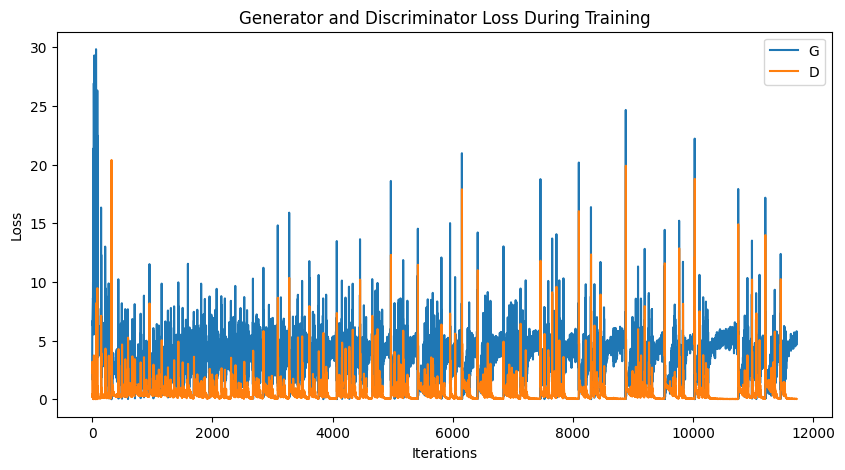

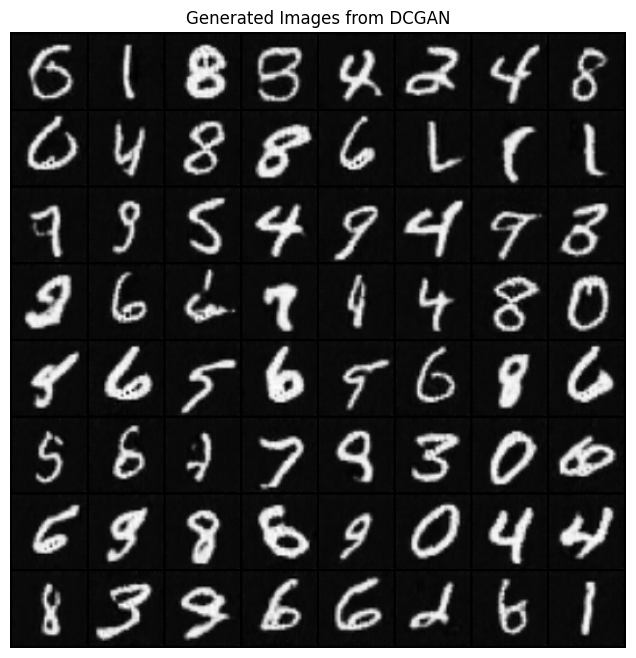

In [10]:
# Plot training losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Display generated images in a grid
import torchvision.utils as vutils

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images from DCGAN")
# Make a grid of images (8x8 grid from 64 images)
plt.imshow(np.transpose(vutils.make_grid(img_list[-1], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()